# Product Analytics and A/B Testing

Автор: Алексей Поляков  
Дата: 15.06.2026

Проект объединяет два аналитических кейса:

1. статистическое сравнение активности пользователей книжного сервиса в Москве и Санкт-Петербурге;
2. оценку результатов A/B-теста нового интерфейса интернет-магазина BitMotion Kit.

В работе выполнены предобработка данных, проверка качества экспериментальных групп, расчёт конверсии и требуемого размера выборки, статистическое тестирование и подготовка рекомендаций для бизнеса.


## Часть 1. Сравнение активности пользователей книжного сервиса

Проверяется гипотеза о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг, чем пользователи из Москвы.


## Цели и задачи проекта

<font color='#777778'>

### Цель проекта

**Проверка статистической гипотезы:** Пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

### Задачи проекта
Проверка корректности проведения A/B теста по проверке гипотезы:
- **Нулевая гипотеза H₀:** μСПб ≤ μМосква (среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве)
- **Альтернативная гипотеза H₁:** μСПб > μМосква (среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо)
</font>

## Описание данных

<font color='#777778'>Данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности представлены из файла `yandex_knigi_data.csv`.</font>

## Содержимое проекта

<font color='#777778'>
    
### Основные шаги:

1. Проверка на дубликаты в идентификаторах пользователей (puid)
2. Сравнение размеров групп (Москва vs Санкт-Петербург)
3. Расчёт описательной статистики для групп
4. Визуализация распределения данных
5. Проверка однородности дисперсий (тест Левена)
6. Односторонняя проверка гипотезы с двумя выборками (t-тест)
7. Интерпретация результатов и формулировка вывода
8. Подготовка аналитической записки.</font>

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
import statsmodels.stats.api as sms
from scipy.stats import chi2_contingency
from scipy.stats import norm
from scipy import stats

In [2]:
# Чтение CSV-файла с историческими данными о сессиях пользователей
yandex_knigi_data = pd.read_csv('../data/yandex_knigi_data.csv', index_col=0)

# Вывод первых пять строк датафрейма
display (yandex_knigi_data.head())

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [3]:
# Проверка на дубликаты по puid
duplicates = yandex_knigi_data[yandex_knigi_data.duplicated(subset=['puid'], keep=False)]

# Количество дубликатов
num_duplicates = duplicates['puid'].nunique()
total_duplicate_rows = len(duplicates)

print(f"Количество уникальных puid с дубликатами: {num_duplicates}")
print(f"Общее количество записей-дубликатов: {total_duplicate_rows}")

# Показываем дубликаты
if num_duplicates > 0:
    print("\nДубликаты puid:")
    display(duplicates.groupby('puid').size().reset_index(name='count'))
else:
    print("\nДубликатов в идентификаторах пользователей (puid) нет.")

Количество уникальных puid с дубликатами: 244
Общее количество записей-дубликатов: 488

Дубликаты puid:


,puid,count
0,2637041,2
1,9979490,2
2,10597984,2
3,10815097,2
4,13626259,2
...,...,...
239,1130000018516717,2
240,1130000018954257,2
241,1130000020425037,2
242,1130000023864516,2


<font color='#777778'>
    
Обнаружено **244** строки дубликата, которые необходимо удалить.</font>

In [4]:
# Удаление дубликатов по puid, оставляем первую запись
df_clean = yandex_knigi_data.drop_duplicates(subset=['puid'], keep='first')

# Количество удалённых записей
removed_count = len(yandex_knigi_data) - len(df_clean)
print(f"Удалено дубликатов: {removed_count}")
print(f"Осталось записей: {len(df_clean)}")


Удалено дубликатов: 244
Осталось записей: 8540


In [5]:
# Фильтрация по городам
moscow_df = df_clean[df_clean['city'] == 'Москва']
spb_df = df_clean[df_clean['city'] == 'Санкт-Петербург']

# Размеры групп
print(f"Количество пользователей в Москве: {len(moscow_df)}")
print(f"Количество пользователей в Санкт-Петербурге: {len(spb_df)}")
print(f"Разница в размерах групп: {len(moscow_df) - len(spb_df)}")

# Процентное соотношение
total = len(moscow_df) + len(spb_df)
print(f"Процент Москвы: {len(moscow_df) / total * 100:.1f}%")
print(f"Процент СПб: {len(spb_df) / total * 100:.1f}%")

Количество пользователей в Москве: 6234
Количество пользователей в Санкт-Петербурге: 2306
Разница в размерах групп: 3928
Процент Москвы: 73.0%
Процент СПб: 27.0%


In [6]:
# Фильтрация по городам
moscow_df = df_clean[df_clean['city'] == 'Москва']
spb_df = df_clean[df_clean['city'] == 'Санкт-Петербург']
# Сравнение статистик:
print("\n" + "=" * 50)
print("СРАВНЕНИЕ СТАТИСТИК")
print("=" * 50)

# Вычисление разницы в процентах (Москва vs Санкт-Петербург)
diff_pct = [
    f"{(len(moscow_df) - len(spb_df)) / len(spb_df) * 100:.1f}%",
    f"{(moscow_df['puid'].nunique() - spb_df['puid'].nunique()) / spb_df['puid'].nunique() * 100:.1f}%",
    f"{(moscow_df['hours'].mean() - spb_df['hours'].mean()) / spb_df['hours'].mean() * 100:.1f}%",
    f"{(moscow_df['hours'].median() - spb_df['hours'].median()) / spb_df['hours'].median() * 100:.1f}%",
    f"{(moscow_df['hours'].min() - spb_df['hours'].min()) / spb_df['hours'].min() * 100:.1f}%",
    f"{(moscow_df['hours'].max() - spb_df['hours'].max()) / spb_df['hours'].max() * 100:.1f}%",
    f"{(moscow_df['hours'].std() - spb_df['hours'].std()) / spb_df['hours'].std() * 100:.1f}%"
]

comparison = pd.DataFrame({
    'Метрика': ['Количество записей', 'Уникальных пользователей', 
                'Среднее hours', 'Медиана hours', 'Мин hours', 'Макс hours', 'Std hours'],
    'Москва': [len(moscow_df), moscow_df['puid'].nunique(),
               moscow_df['hours'].mean(), moscow_df['hours'].median(),
               moscow_df['hours'].min(), moscow_df['hours'].max(),
               moscow_df['hours'].std()],
    'Санкт-Петербург': [len(spb_df), spb_df['puid'].nunique(),
                        spb_df['hours'].mean(), spb_df['hours'].median(),
                        spb_df['hours'].min(), spb_df['hours'].max(),
                        spb_df['hours'].std()],
    'Разница % (Москва vs СПб)': diff_pct
})

print(comparison.to_string(index=False))


СРАВНЕНИЕ СТАТИСТИК
                 Метрика      Москва  Санкт-Петербург Разница % (Москва vs СПб)
      Количество записей 6234.000000      2306.000000                    170.3%
Уникальных пользователей 6234.000000      2306.000000                    170.3%
           Среднее hours   10.881092        11.264433                     -3.4%
           Медиана hours    0.924498         0.875355                      5.6%
               Мин hours    0.000018         0.000025                    -28.1%
              Макс hours  857.209373       978.764775                    -12.4%
               Std hours   36.851683        39.831755                     -7.5%


Москва: 6234 пользователей
СПб: 2306 пользователей


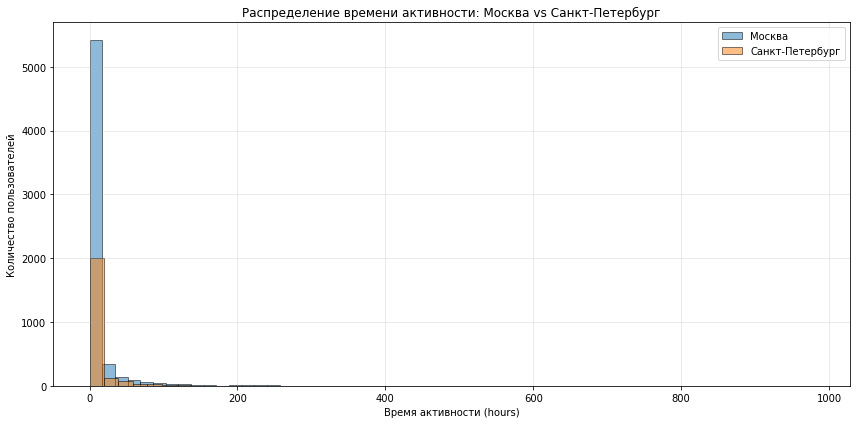

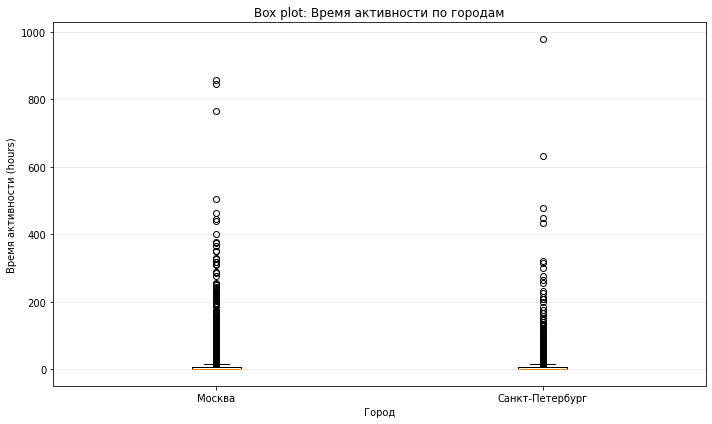

In [7]:

#  Фильтрация по городам 
moscow_df = df_clean[df_clean['city'] == 'Москва']
spb_df = df_clean[df_clean['city'] == 'Санкт-Петербург']

print(f"Москва: {len(moscow_df)} пользователей")
print(f"СПб: {len(spb_df)} пользователей")

# Визуализация 
plt.figure(figsize=(12, 6))
plt.hist(moscow_df['hours'], bins=50, alpha=0.5, label='Москва', edgecolor='black')
plt.hist(spb_df['hours'], bins=50, alpha=0.5, label='Санкт-Петербург', edgecolor='black')
plt.xlabel('Время активности (hours)')
plt.ylabel('Количество пользователей')
plt.title('Распределение времени активности: Москва vs Санкт-Петербург')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('distribution_histogram.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.boxplot([moscow_df['hours'], spb_df['hours']], labels=['Москва', 'Санкт-Петербург'])
plt.xlabel('Город')
plt.ylabel('Время активности (hours)')
plt.title('Box plot: Время активности по городам')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('boxplot.png')
plt.show()

<font color='#777778'>
    
1. **Размер выборки**: В Москве значительно больше пользователей (6234 vs 2306) — в 2.7 раза больше

2. **Средняя активность**: Санкт-Петербург показывает **немного выше среднее время** (11.26 vs 10.88 часов), но разница небольшая (3.4%)

3. **Медианная активность**: Москва показывает **выше медиану** (0.92 vs 0.88 часов) — это означает, что "обычный" пользователь в Москве активнее

4. **Разброс данных**: Санкт-Петербург имеет **больше вариабельность** (Std = 39.83 vs 36.85) — активность пользователей более неравномерная

### Вывод

**Петербургские пользователи в среднем активнее** (+3.4% по среднему), но **московские пользователи более стабильны** (выше медиана, меньше разброс). Разница в активности небольшая, основная отличия — в размере аудитории (Москва >> СПб).</font>

## 2. Статистическая проверка гипотезы


In [8]:
# 1. Выделяем выборки по городам
spb_hours = df_clean[df_clean['city'] == 'Санкт-Петербург']['hours']
moscow_hours = df_clean[df_clean['city'] == 'Москва']['hours']

# 2. Проверка статистик (для подтверждения)
print("Статистики по городам:")
print(f"Санкт-Петербург: n={len(spb_hours)}, mean={spb_hours.mean():.4f}, std={spb_hours.std():.4f}")
print(f"Москва: n={len(moscow_hours)}, mean={moscow_hours.mean():.4f}, std={moscow_hours.std():.4f}")

# 3. Односторонний t-тест для двух независимых выборок
# equal_var=False использует t-тест Уэлча (не предполагаем равенство дисперсий)
t_stat, p_value = stats.ttest_ind(
    spb_hours, 
    moscow_hours, 
    equal_var=False, 
    alternative='greater'
)

# 4. Вывод результатов
print("\n==================================================")
print("РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ")
print("==================================================")
print(f"Нулевая гипотеза H0: μСПб ≤ μМосква")
print(f"Альтернативная гипотеза H1: μСПб > μМосква")
print(f"\nt-статистика: {t_stat:.4f}")
print(f"p-value (односторонний): {p_value:.4f}")

# 5. Статистическое решение
alpha = 0.05  # уровень значимости 5%
if p_value < alpha:
    print(f"\n p-value < {alpha}: ОТВЕРГАЕМ НУЛЕВУЮ ГИПОТЕЗУ")
    print("  Среднее время активности в Санкт-Петербурге статистически значимо больше, чем в Москве.")
    print("  Гипотеза H1 подтверждается.")
else:
    print(f"\n p-value >= {alpha}: НЕ ОТВЕРГАЕМ НУЛЕВУЮ ГИПОТЕЗУ")
    print("  Недостаточно доказательств, что среднее время чтения и прослушивания книг в Санкт-Петербурге больше.")
    print("  Гипотеза H1 не подтверждается статистически.")

Статистики по городам:
Санкт-Петербург: n=2306, mean=11.2644, std=39.8318
Москва: n=6234, mean=10.8811, std=36.8517

РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗЫ
Нулевая гипотеза H0: μСПб ≤ μМосква
Альтернативная гипотеза H1: μСПб > μМосква

t-статистика: 0.4028
p-value (односторонний): 0.3436

 p-value >= 0.05: НЕ ОТВЕРГАЕМ НУЛЕВУЮ ГИПОТЕЗУ
  Недостаточно доказательств, что среднее время чтения и прослушивания книг в Санкт-Петербурге больше.
  Гипотеза H1 не подтверждается статистически.


<font color='#777778'>

## Аналитическая записка: A/B-тест сравнения времени активности пользователей (СПб vs Москва)

#### 1. Выбранный тип теста и уровень значимости

- **Тип теста**: Односторонний t-тест для двух независимых выборок с неравными дисперсиями (t-тест Уэлча)
- **Параметры**: `equal_var=False`, `alternative='greater'`
- **Уровень статистической значимости**: α = 0.05 (5%)

**Обоснование выбора t-теста Уэлча**:
- Гипотеза формулируется о сравнении **средних значений** (μСПб > μМосква)
- Дисперсии выборок неравные (Std СПб = 39.83 vs Std Москва = 36.85)
- Большие выборки (nСПб = 2306, nМосква = 6234) обеспечивают применимость благодаря центральной предельной теореме

#### 2. Результаты тестирования

| Метрика | Санкт-Петербург | Москва | Разница |
|---------|----------------|--------|---------|
| Количество записей | 2306 | 6234 | — |
| Среднее hours | 11.2644 | 10.8811 | +3.4% |
| Стандартное отклонение | 39.8318 | 36.8517 | — |

**Статистические показатели теста**:
- **t-статистика**: 0.4028
- **p-value (односторонний)**: 0.3436

#### 3. Вывод и интерпретация

**Решение**: p-value (0.3436) ≥ α (0.05) → **НЕ ОТВЕРГАЕМ нулевую гипотезу H0**

**Интерпретация**: 
Недостаточно статистических доказательств, чтобы утверждать, что пользователи из Санкт-Петербурга проводят в приложении больше времени за чтением и прослушиванием книг, чем пользователи из Москвы. Разница в средних значениях (11.26 vs 10.88 часов, +3.4%) **не является статистически значимой**.

Гипотеза H1 (μСПб > μМосква) **не подтверждается** на 5% уровне значимости.

#### 4. Возможные причины полученных результатов:
##### Причина 1: Высокая вариабельность данных (большой std)
Стандартное отклонение (37-40 часов) примерно в 3.5 раза превышает разницу между средними значениями (0.38 часа). Правый длинный хвост распределения с выбросами (максимум до 857-978 часов) увеличивает дисперсию, что снижает мощность теста и делает малую разницу в средних статистически незначимой.
##### Причина 2: Недостаточная мощность теста для обнаружения малого эффекта
Разница в средних значениях составляет лишь 3.4% (0.38 часа). При текущем размере выборок и высокой вариабельности минимальный обнаруживаемый эффект (MDE) может быть больше 3.4%, то есть тест не обладает достаточной чувствительностью для выявления такого небольшого различия. Для подтверждения гипотезы потребовались бы либо значительно большие выборки, либо более выраженная разница между городами.</font>

----

# Часть 2. A/B-тест нового интерфейса интернет-магазина


Интернет-магазин геймифицированных товаров для здорового образа жизни BitMotion Kit планирует расширение ассортимента. Перед запуском необходимо оценить, повышает ли упрощённый интерфейс конверсию зарегистрированных пользователей в покупателей не менее чем на 3 процентных пункта.


<font color='#777778'>
    
### Цели исследования A/B-теста для интернет-магазина BitMotion Kit

##### Главная цель
Оценить эффективность новой версии интерфейса сайта интернет-магазина BitMotion Kit в повышении конверсии пользователей в покупателей.

##### Конкретные цели исследования

1. **Оценить корректность проведения A/B-теста**
   - Проверить равномерность распределения пользователей по группам (A — контрольная, B — новый интерфейс)
   - Обнаружить и исключить пересечения с конкурирующими тестами
   - Подтвердить отсутствие пользователей в нескольких группах одного теста
   - Оценить достаточность выборки для статистически значимых результатов

2. **Проанализировать результаты теста**
   - Рассчитать конверсию в покупку для каждой группы (в течение первых 7 дней после регистрации)
   - Проверить статистическую значимость разницы конверсий используя Z-тест для пропорций
   - Оценить, достигается ли целевое увеличение конверсии как минимум на 3 процентных пункта (согласно ТЗ)
   - Построить доверительный интервал для разницы конверсий

3. **Принять бизнес-решение**
   - Определить, следует ли принимать новую версию интерфейса для всех пользователей
   - Сформулировать рекомендации по дальнейшему развитию магазина перед расширением ассортимента товаров.</font>

In [9]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)
display (participants.head())
display (events.head())

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


<font color='#777778'>Данные загружены, общая структура и формат данных корректные.</font>

## 3. Проверка корректности проведения A/B-теста

Проверяются соответствие групп техническому заданию, равномерность распределения пользователей, пересечения между группами и конкурирующими экспериментами, а также однородность распределения по устройствам.


In [10]:
# Выделяем пользователей, участвующих в тесте interface_eu_test
df_test = participants[participants['ab_test'] == 'interface_eu_test']

print("=== Пользователи теста interface_eu_test (оригинальные) ===")
print(f"Количество записей в тесте: {len(df_test)}")
print(f"Уникальных пользователей: {df_test['user_id'].nunique()}")
print("\n=== Распределение по группам ===")
print(df_test['group'].value_counts())

=== Пользователи теста interface_eu_test (оригинальные) ===
Количество записей в тесте: 10850
Уникальных пользователей: 10850

=== Распределение по группам ===
B    5467
A    5383
Name: group, dtype: int64


In [11]:
print("=== Проверка: Соответствие требованиям ТЗ ===")
print("Требования ТЗ:")
print("  - Название теста: interface_eu_test")
print("  - Группы: A (контрольная), B (новый интерфейс)")

# Проверка названий групп
unique_groups = df_test['group'].unique()
print(f"\nФактические группы в тесте: {unique_groups}")

expected_groups = ['A', 'B']
groups_match = set(unique_groups) == set(expected_groups)

print(f"Группы соответствуют ТЗ: {groups_match}")

if not groups_match:
    print(f"❌ ОШИБКА: Ожидались группы {expected_groups}, но получены {unique_groups}")
else:
    print("✅ Группы соответствуют требованиям ТЗ")

=== Проверка: Соответствие требованиям ТЗ ===
Требования ТЗ:
  - Название теста: interface_eu_test
  - Группы: A (контрольная), B (новый интерфейс)

Фактические группы в тесте: ['B' 'A']
Группы соответствуют ТЗ: True
✅ Группы соответствуют требованиям ТЗ


In [12]:
print("=== Проверка: Равномерность распределения (оригинальные данные) ===")

group_counts = df_test['group'].value_counts()
print("Количество пользователей по группам:")
print(group_counts)

total_users = len(df_test)
expected_count = total_users / 2

print(f"\nОбщее количество пользователей: {total_users}")
print(f"Ожидаемое количество в каждой группе (50/50): {expected_count}")

# Процентное распределение
group_percentages = df_test['group'].value_counts(normalize=True) * 100
print("\nПроцентное распределение:")
print(group_percentages)

# χ²-тест для проверки равномерности
observed = group_counts.values
expected = [total_users / 2, total_users / 2]

chi2_stat, p_value, _, _ = chi2_contingency([observed, expected])

print(f"\nχ²-статистика: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"❌ p-value < {alpha}: Распределение НЕ равномерное (есть SRM)")
else:
    print(f"✅ p-value >= {alpha}: Распределение равномерное (нет SRM)")

# Отклонение от 50%
print("\nОтклонение от ожидаемого 50%:")
for group, count in group_counts.items():
    percentage = (count / total_users) * 100
    deviation = abs(percentage - 50)
    print(f"  Группа {group}: {percentage:.2f}% (отклонение: {deviation:.2f}%)")

=== Проверка: Равномерность распределения (оригинальные данные) ===
Количество пользователей по группам:
B    5467
A    5383
Name: group, dtype: int64

Общее количество пользователей: 10850
Ожидаемое количество в каждой группе (50/50): 5425.0

Процентное распределение:
B    50.387097
A    49.612903
Name: group, dtype: float64

χ²-статистика: 0.3099
p-value: 0.5778
✅ p-value >= 0.05: Распределение равномерное (нет SRM)

Отклонение от ожидаемого 50%:
  Группа B: 50.39% (отклонение: 0.39%)
  Группа A: 49.61% (отклонение: 0.39%)


In [13]:
print("=== Проверка: Пересечения пользователей в группах одного теста ===")

# Пользователи в нескольких группах ОДНОГО теста
users_groups = df_test.groupby('user_id')['group'].nunique()
multiple_group_users = users_groups[users_groups > 1]

print(f"Пользователей в нескольких группах теста interface_eu_test: {len(multiple_group_users)}")

if len(multiple_group_users) > 0:
    print("❌ ОШИБКА: найдены пользователи одновременно в разных группах")
else:
    print("✅ Нет пользователей в нескольких группах одного теста")

=== Проверка: Пересечения пользователей в группах одного теста ===
Пользователей в нескольких группах теста interface_eu_test: 0
✅ Нет пользователей в нескольких группах одного теста


In [14]:
print("=== Проверка: Пересечения пользователей между тестами ===")

# Пользователи в нескольких тестах
all_users_tests = participants.groupby('user_id')['ab_test'].nunique()
multiple_test_users = all_users_tests[all_users_tests > 1]

print(f"Пользователей в нескольких тестах: {len(multiple_test_users)}")

if len(multiple_test_users) > 0:
    print("❌ ОШИБКА: найдены пользователи одновременно в разных тестах")
    print(f"Количество пользователей для исключения: {len(multiple_test_users)}")
    
    # Показать примеры пересечений
    print("\nПримеры пересечений (первые 5):")
    for user_id in multiple_test_users.index[:5]:
        user_data = participants[participants['user_id'] == user_id][['user_id', 'ab_test', 'group']]
        tests_groups = user_data.groupby('ab_test')['group'].apply(list).to_dict()
        print(f"  {user_id}: {tests_groups}")
else:
    print("✅ Нет пользователей в нескольких тестах")

=== Проверка: Пересечения пользователей между тестами ===
Пользователей в нескольких тестах: 887
❌ ОШИБКА: найдены пользователи одновременно в разных тестах
Количество пользователей для исключения: 887

Примеры пересечений (первые 5):
  001064FEAAB631A1: {'interface_eu_test': ['A'], 'recommender_system_test': ['B']}
  00341D8401F0F665: {'interface_eu_test': ['B'], 'recommender_system_test': ['A']}
  0082295A41A867B5: {'interface_eu_test': ['A'], 'recommender_system_test': ['A']}
  00E68F103C66C1F7: {'interface_eu_test': ['A'], 'recommender_system_test': ['A']}
  00EFA157F7B6E1C4: {'interface_eu_test': ['B'], 'recommender_system_test': ['A']}


<font color='#777778'>Обнаружены **887** пересечений пользователей между тестами. Это может влиять на объективность оценки, поэтому необходимо исключить таких пользователей из выборок.</font>

In [15]:
print("=== Фильтрация пользователей с пересечениями ===")

# Получаем user_id пользователей в нескольких тестах
multiple_test_users_ids = multiple_test_users.index.tolist()
print(f"Количество пользователей для исключения: {len(multiple_test_users_ids)}")

# Фильтруем df_test, исключая этих пользователей
df_test_clean = df_test[df_test['user_id'].isin(multiple_test_users_ids) == False]

print(f"\nОригинальное количество пользователей: {len(df_test)}")
print(f"Пользователей после фильтрации: {len(df_test_clean)}")
print(f"Исключено: {len(df_test) - len(df_test_clean)}")
print(f"Процент исключённых: {(len(df_test) - len(df_test_clean)) / len(df_test) * 100:.2f}%")

print("\n=== Распределение после фильтрации ===")
print(df_test_clean['group'].value_counts())

=== Фильтрация пользователей с пересечениями ===
Количество пользователей для исключения: 887

Оригинальное количество пользователей: 10850
Пользователей после фильтрации: 9963
Исключено: 887
Процент исключённых: 8.18%

=== Распределение после фильтрации ===
B    5011
A    4952
Name: group, dtype: int64


In [16]:
print("=== Повторная проверка равномерности (очищенные данные) ===")

group_counts_clean = df_test_clean['group'].value_counts()
print("Количество пользователей по группам после фильтрации:")
print(group_counts_clean)

total_users_clean = len(df_test_clean)
expected_count_clean = total_users_clean / 2

print(f"\nОбщее количество пользователей после фильтрации: {total_users_clean}")
print(f"Ожидаемое количество в каждой группе (50/50): {expected_count_clean}")

# Процентное распределение
group_percentages_clean = df_test_clean['group'].value_counts(normalize=True) * 100
print("\nПроцентное распределение после фильтрации:")
print(group_percentages_clean)

# χ²-тест для очищенных данных
observed_clean = group_counts_clean.values
expected_clean = [total_users_clean / 2, total_users_clean / 2]

chi2_stat_clean, p_value_clean, _, _ = chi2_contingency([observed_clean, expected_clean])

print(f"\nχ²-статистика: {chi2_stat_clean:.4f}")
print(f"p-value: {p_value_clean:.4f}")

if p_value_clean >= alpha:
    print(f"✅ p-value >= {alpha}: Распределение равномерное (нет SRM)")
else:
    print(f"❌ p-value < {alpha}: Распределение НЕ равномерное")
print("="*70)

=== Повторная проверка равномерности (очищенные данные) ===
Количество пользователей по группам после фильтрации:
B    5011
A    4952
Name: group, dtype: int64

Общее количество пользователей после фильтрации: 9963
Ожидаемое количество в каждой группе (50/50): 4981.5

Процентное распределение после фильтрации:
B    50.296096
A    49.703904
Name: group, dtype: float64

χ²-статистика: 0.1631
p-value: 0.6864
✅ p-value >= 0.05: Распределение равномерное (нет SRM)


In [17]:
print("=== Повторная проверка: Пересечения между тестами (очищенные данные) ===")

# Проверяем только очищенные данные на пересечения между тестами
# (теперь все пользователи в df_test_clean участвуют только в interface_eu_test)
users_tests_clean = df_test_clean.groupby('user_id')['ab_test'].nunique()
multiple_tests_clean = users_tests_clean[users_tests_clean > 1]

print(f"Пользователей в нескольких тестах после фильтрации: {len(multiple_tests_clean)}")

if len(multiple_tests_clean) > 0:
    print("❌ ОШИБКА: остались пользователи в нескольких тестах")
else:
    print("✅ Нет пользователей в нескольких тестах (пересечения устранены)")

=== Повторная проверка: Пересечения между тестами (очищенные данные) ===
Пользователей в нескольких тестах после фильтрации: 0
✅ Нет пользователей в нескольких тестах (пересечения устранены)


In [18]:
print("\n" + "="*70)
print("=== ОБЩИЙ ВЫВОД ПО КОРРЕКТНОСТИ ПРОВЕДЕНИЯ ТЕСТА ===")
print("="*70)

# Результаты проверок ORIGINAЛЬНЫХ данных
print("\n--- Исходные данные (без фильтрации) ---")
checks_original = {
    "Группы соответствуют ТЗ (A и B)": groups_match,
    "Распределение равномерное (нет SRM)": p_value >= alpha,
    "Нет пользователей в нескольких группах": len(multiple_group_users) == 0,
    "Нет пересечений с конкурирующими тестами": len(multiple_test_users) == 0
}

for check_name, passed in checks_original.items():
    status = "✅" if passed else "❌"
    print(f"{status} {check_name}")

all_passed_original = all(checks_original.values())
print(f"\nИсходный тест корректен: {all_passed_original}")

# Результаты проверок ОЧИЩЕННЫХ данных
print("\n--- Очищенные данные (после фильтрации пересечений) ---")
checks_clean = {
    "Группы соответствуют ТЗ (A и B)": groups_match,
    "Распределение равномерное (нет SRM)": p_value_clean >= alpha,
    "Нет пользователей в нескольких группах": len(multiple_group_users) == 0,
    "Нет пересечений с конкурирующими тестами": len(multiple_tests_clean) == 0
}

for check_name, passed in checks_clean.items():
    status = "✅" if passed else "❌"
    print(f"{status} {check_name}")

all_passed_clean = all(checks_clean.values())
print(f"\nОчищенный тест корректен: {all_passed_clean}")

print("\n" + "="*70)
if not all_passed_original and all_passed_clean:
    print("✅ ТЕСТ ПОСЛЕ ФИЛЬТРАЦИИ: ПРОЙДЕН КОРРЕКТНО")
    print(f"Исключено {len(multiple_test_users)} пользователей, участвующих в конкурирующем тесте")
    print("Результаты теста можно анализировать дальше на данных df_test_clean")
elif all_passed_original:
    print("✅ ТЕСТ ИСХОДНЫЙ: ПРОЙДЕН КОРРЕКТНО (фильтрация не нужна)")
    print("Результаты теста можно анализировать дальше на данных df_test")
else:
    print("❌ ТЕСТ НЕКОРРЕКТЕН даже после фильтрации")
    print("Нужно устранить другие проблемы перед анализом результатов")
print("="*70)


=== ОБЩИЙ ВЫВОД ПО КОРРЕКТНОСТИ ПРОВЕДЕНИЯ ТЕСТА ===

--- Исходные данные (без фильтрации) ---
✅ Группы соответствуют ТЗ (A и B)
✅ Распределение равномерное (нет SRM)
✅ Нет пользователей в нескольких группах
❌ Нет пересечений с конкурирующими тестами

Исходный тест корректен: False

--- Очищенные данные (после фильтрации пересечений) ---
✅ Группы соответствуют ТЗ (A и B)
✅ Распределение равномерное (нет SRM)
✅ Нет пользователей в нескольких группах
✅ Нет пересечений с конкурирующими тестами

Очищенный тест корректен: True

✅ ТЕСТ ПОСЛЕ ФИЛЬТРАЦИИ: ПРОЙДЕН КОРРЕКТНО
Исключено 887 пользователей, участвующих в конкурирующем тесте
Результаты теста можно анализировать дальше на данных df_test_clean


In [19]:
print("=== Распределение по устройствам (очищенные данные) ===")

device_counts_clean = df_test_clean['device'].value_counts()
print("Количество пользователей по устройствам после фильтрации:")
print(device_counts_clean)

print("\nПроцентное распределение по устройствам:")
device_percentages_clean = df_test_clean['device'].value_counts(normalize=True) * 100
print(device_percentages_clean)

# Проверка баланса устройств между группами
print("\nРаспределение устройств по группам после фильтрации:")
device_by_group_clean = df_test_clean.groupby(['group', 'device']).size().unstack(fill_value=0)
print(device_by_group_clean)

=== Распределение по устройствам (очищенные данные) ===
Количество пользователей по устройствам после фильтрации:
Android    4482
PC         2525
iPhone     1930
Mac        1026
Name: device, dtype: int64

Процентное распределение по устройствам:
Android    44.986450
PC         25.343772
iPhone     19.371675
Mac        10.298103
Name: device, dtype: float64

Распределение устройств по группам после фильтрации:
device  Android  Mac    PC  iPhone
group                             
A          2264  515  1223     950
B          2218  511  1302     980


<font color='#777778'>Распределение по типам устройств в группах однородное.</font>

### 3.1. Подготовка событий пользователей теста

Для дальнейшего анализа оставлены события пользователей очищенной выборки и изучена структура пользовательской активности.


In [20]:
print("=== Фильтрация событий для пользователей теста interface_eu_test ===")

# Получаем user_id пользователей из очищенного теста df_test_clean
test_users_clean = df_test_clean['user_id'].unique()
print(f"Количество уникальных пользователей в очищенном тесте: {len(test_users_clean)}")

# Фильтруем события events, оставляя только события этих пользователей
events_test_clean = events[events['user_id'].isin(test_users_clean)]

print(f"\nОригинальное количество событий в events: {len(events)}")
print(f"Количество событий для пользователей теста: {len(events_test_clean)}")
print(f"Исключено событий: {len(events) - len(events_test_clean)}")
print(f"Процент оставшихся событий: {len(events_test_clean) / len(events) * 100:.2f}%")

print("\n=== Структура отфильтрованных событий ===")
print(f"Столбцы: {events_test_clean.columns.tolist()}")
display(events_test_clean.head(10))

=== Фильтрация событий для пользователей теста interface_eu_test ===
Количество уникальных пользователей в очищенном тесте: 9963

Оригинальное количество событий в events: 787286
Количество событий для пользователей теста: 73815
Исключено событий: 713471
Процент оставшихся событий: 9.38%

=== Структура отфильтрованных событий ===
Столбцы: ['user_id', 'event_dt', 'event_name', 'details']


,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0
69068,8FCA593F7D87FECA,2020-12-06 21:34:19,registration,0.0
69718,C64851EFACDDDFEB,2020-12-06 22:30:07,registration,-2.38
69908,612F81CFCAD7D062,2020-12-06 22:53:21,registration,-4.75
70291,DD3B49B4AF10F101,2020-12-06 23:32:12,registration,0.0
70392,9F4B7C7D64845781,2020-12-06 23:42:49,registration,-2.38


In [21]:
print("=== Анализ типов событий ===")

print("Количество событий по типам:")
event_types = events_test_clean['event_name'].value_counts()
print(event_types)

print("\nПроцентное распределение по типам событий:")
event_percentages = events_test_clean['event_name'].value_counts(normalize=True) * 100
print(event_percentages)

=== Анализ типов событий ===
Количество событий по типам:
login           27360
product_page    17614
registration     9963
purchase         9487
product_cart     9391
Name: event_name, dtype: int64

Процентное распределение по типам событий:
login           37.065637
product_page    23.862359
registration    13.497257
purchase        12.852401
product_cart    12.722346
Name: event_name, dtype: float64


In [22]:
print("=== Фильтрация событий регистрации и покупки ===")

# Фильтруем только события registration и purchase
relevant_events_clean = events_test_clean[
    events_test_clean['event_name'].isin(['registration', 'purchase'])
]

print(f"Количество релевантных событий (registration + purchase): {len(relevant_events_clean)}")
print(f"Из общего количества событий: {len(events_test_clean)}")
print(f"Процент релевантных событий: {len(relevant_events_clean) / len(events_test_clean) * 100:.2f}%")

print("\n=== Распределение релевантных событий ===")
print(relevant_events_clean['event_name'].value_counts())

print("\n=== Первые 10 релевантных событий ===")
display(relevant_events_clean.head(10))

=== Фильтрация событий регистрации и покупки ===
Количество релевантных событий (registration + purchase): 19450
Из общего количества событий: 73815
Процент релевантных событий: 26.35%

=== Распределение релевантных событий ===
registration    9963
purchase        9487
Name: event_name, dtype: int64

=== Первые 10 релевантных событий ===


,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0
69068,8FCA593F7D87FECA,2020-12-06 21:34:19,registration,0.0
69718,C64851EFACDDDFEB,2020-12-06 22:30:07,registration,-2.38
69908,612F81CFCAD7D062,2020-12-06 22:53:21,registration,-4.75
70291,DD3B49B4AF10F101,2020-12-06 23:32:12,registration,0.0
70392,9F4B7C7D64845781,2020-12-06 23:42:49,registration,-2.38


In [23]:
print("=== Сохранение отфильтрованных данных ===")

# Сохраняем отфильтрованные данные
import os
os.makedirs('../output', exist_ok=True)

events_test_clean.to_csv('../output/events_test_clean.csv', index=False)
relevant_events_clean.to_csv('../output/relevant_events_clean.csv', index=False)

print("✅ Данные сохранены:")
print("  - output/events_test_clean.csv (все события пользователей теста)")
print("  - output/relevant_events_clean.csv (только registration и purchase)")

print(f"\nКоличество строк в файлах:")
print(f"  - events_test_clean.csv: {len(events_test_clean)}")
print(f"  - relevant_events_clean.csv: {len(relevant_events_clean)}")

print("\n✅ Данные подготовлены для анализа конверсии (задача 3.2)")

=== Сохранение отфильтрованных данных ===
✅ Данные сохранены:
  - output/events_test_clean.csv (все события пользователей теста)
  - output/relevant_events_clean.csv (только registration и purchase)

Количество строк в файлах:
  - events_test_clean.csv: 73815
  - relevant_events_clean.csv: 19450

✅ Данные подготовлены для анализа конверсии (задача 3.2)


### 3.2. Определение горизонта анализа

Конверсия рассчитывается по событиям, совершённым в течение первых семи дней после регистрации пользователя.


In [24]:
print("=== Преобразование дат и определение времени регистрации ===")

# Создаём явную копию DataFrame, чтобы избежать SettingWithCopyWarning
events_for_analysis = relevant_events_clean.copy()

# Преобразуем event_dt в datetime
events_for_analysis['event_dt'] = pd.to_datetime(events_for_analysis['event_dt'])

# Получаем дату регистрации для каждого пользователя
registration_events = events_for_analysis[events_for_analysis['event_name'] == 'registration']

registration_by_user = registration_events.groupby('user_id')['event_dt'].min().reset_index()
registration_by_user.columns = ['user_id', 'registration_date']

print(f"Количество пользователей с регистрацией: {len(registration_by_user)}")
print("\n=== Пример даты регистрации ===")
display(registration_by_user.head())

=== Преобразование дат и определение времени регистрации ===
Количество пользователей с регистрацией: 9963

=== Пример даты регистрации ===


,user_id,registration_date
0,0002CE61FF2C4011,2020-12-07 04:37:31
1,001E72F50D1C48FA,2020-12-17 15:44:05
2,002412F1EB3F6E38,2020-12-09 09:36:50
3,002540BE89C930FB,2020-12-08 18:06:07
4,0031F1B5E9FBF708,2020-12-14 00:47:10


In [25]:
print("=== Расчет лайфтайма (времени после регистрации) ===")

# Соединяем события с датой регистрации каждого пользователя
events_with_lifetime = events_for_analysis.merge(
    registration_by_user, 
    on='user_id', 
    how='left'
)

# Рассчитываем лайфтайм (в днях)
events_with_lifetime['lifetime_days'] = (
    events_with_lifetime['event_dt'] - events_with_lifetime['registration_date']
) / pd.Timedelta(days=1)

# Округляем до целых дней
events_with_lifetime['lifetime_days'] = events_with_lifetime['lifetime_days'].fillna(0).astype(int)

print(f"Количество событий после соединения: {len(events_with_lifetime)}")
print("\n=== Пример расчета лайфтайма ===")
display(events_with_lifetime[['user_id', 'event_name', 'event_dt', 'registration_date', 'lifetime_days']].head(10))

=== Расчет лайфтайма (времени после регистрации) ===
Количество событий после соединения: 19450

=== Пример расчета лайфтайма ===


,user_id,event_name,event_dt,registration_date,lifetime_days
0,5F506CEBEDC05D30,registration,2020-12-06 14:10:01,2020-12-06 14:10:01,0
1,51278A006E918D97,registration,2020-12-06 14:37:25,2020-12-06 14:37:25,0
2,A0C1E8EFAD874D8B,registration,2020-12-06 17:20:22,2020-12-06 17:20:22,0
3,275A8D6254ACF530,registration,2020-12-06 19:36:54,2020-12-06 19:36:54,0
4,0B704EB2DC7FCA4B,registration,2020-12-06 19:42:20,2020-12-06 19:42:20,0
5,8FCA593F7D87FECA,registration,2020-12-06 21:34:19,2020-12-06 21:34:19,0
6,C64851EFACDDDFEB,registration,2020-12-06 22:30:07,2020-12-06 22:30:07,0
7,612F81CFCAD7D062,registration,2020-12-06 22:53:21,2020-12-06 22:53:21,0
8,DD3B49B4AF10F101,registration,2020-12-06 23:32:12,2020-12-06 23:32:12,0
9,9F4B7C7D64845781,registration,2020-12-06 23:42:49,2020-12-06 23:42:49,0


In [26]:
print("=== Фильтрация событий в течение первых 7 дней ===")

# Фильтруем события, где лайфтайм <= 7 дней (первых 7 дней: 0, 1, 2, 3, 4, 5, 6, 7)
events_7days = events_with_lifetime[events_with_lifetime['lifetime_days'] <= 7]

print(f"Оригинальное количество релевантных событий: {len(relevant_events_clean)}")
print(f"События в течение 7 дней после регистрации: {len(events_7days)}")
print(f"Исключено событий (> 7 дней): {len(relevant_events_clean) - len(events_7days)}")
print(f"Процент оставшихся событий: {len(events_7days) / len(relevant_events_clean) * 100:.2f}%")

print("\n=== Распределение событий по лайфтайму (до фильтрации) ===")
lifetime_distribution_before = events_with_lifetime['lifetime_days'].value_counts().sort_index()
print(lifetime_distribution_before)

print("\n=== Распределение событий по лайфтайму (после фильтрации) ===")
lifetime_distribution_after = events_7days['lifetime_days'].value_counts().sort_index()
print(lifetime_distribution_after)

=== Фильтрация событий в течение первых 7 дней ===
Оригинальное количество релевантных событий: 19450
События в течение 7 дней после регистрации: 16755
Исключено событий (> 7 дней): 2695
Процент оставшихся событий: 86.14%

=== Распределение событий по лайфтайму (до фильтрации) ===
0     10773
1       945
2      1037
3       984
4       909
5       836
6       641
7       630
8       505
9       399
10      383
11      228
12      227
13      221
14      166
15      173
16      111
17       78
18       57
19       71
20       34
21       26
22       16
Name: lifetime_days, dtype: int64

=== Распределение событий по лайфтайму (после фильтрации) ===
0    10773
1      945
2     1037
3      984
4      909
5      836
6      641
7      630
Name: lifetime_days, dtype: int64


### 3.3. Оценка достаточности выборки

Размер выборки оценивается при базовой конверсии 30%, мощности теста 80%, доверительной вероятности 95% и минимально обнаруживаемом эффекте 3 процентных пункта.


In [27]:
print("=== Расчет параметров минимального размера выборки для A/B-теста ===")

# Заданные параметры
base_conversion = 0.30  # Базовый показатель конверсии — 30%
power = 0.80  # Мощность теста — 80%
confidence = 0.95  # Достоверность теста — 95%
alpha = 1 - confidence  # Уровень значимости = 0.05

# Минимально обнаруживаемый эффект (MDE) из технического задания
# Гипотеза: конверсия увеличится как минимум на 3 процентных пункта
mde_absolute = 0.03  # 3% абсолютное увеличение (от 30% до 33%)

print("Параметры теста:")
print(f"  Базовая конверсия: {base_conversion * 100:.1f}%")
print(f"  Мощность теста (1-β): {power * 100:.1f}%")
print(f"  Достоверность (1-α): {confidence * 100:.1f}%")
print(f"  Уровень значимости (α): {alpha * 100:.1f}%")
print(f"  Минимально обнаруживаемый эффект (MDE): {mde_absolute * 100:.1f}%")
print(f"  Ожидаемая конверсия в группе B: {(base_conversion + mde_absolute) * 100:.1f}%")

# Расчет Z-значений
z_alpha = norm.ppf(1 - alpha)  # Z для уровня значимости (односторонний)
z_beta = norm.ppf(power)  # Z для мощности

print(f"\nZ-значения:")
print(f"  Z_α (для α={alpha}): {z_alpha:.4f}")
print(f"  Z_β (для мощности={power}): {z_beta:.4f}")

=== Расчет параметров минимального размера выборки для A/B-теста ===
Параметры теста:
  Базовая конверсия: 30.0%
  Мощность теста (1-β): 80.0%
  Достоверность (1-α): 95.0%
  Уровень значимости (α): 5.0%
  Минимально обнаруживаемый эффект (MDE): 3.0%
  Ожидаемая конверсия в группе B: 33.0%

Z-значения:
  Z_α (для α=0.050000000000000044): 1.6449
  Z_β (для мощности=0.8): 0.8416


In [28]:
print("\n=== Расчет размера выборки по формуле ===")

p = base_conversion
delta = mde_absolute

n_per_group = 2 * ((z_alpha + z_beta) ** 2) * p * (1 - p) / (delta ** 2)

print(f"\nФормула: n = 2 * (Z_α + Z_β)² * p * (1-p) / Δ²")
print(f"p (базовая конверсия) = {p}")
print(f"Δ (MDE) = {delta}")
print(f"\nТребуемый размер выборки в каждой группе: {n_per_group:.2f}")
print(f"Требуемый размер выборки округленно: {int(n_per_group) + 1} пользователей в группе")

total_required = 2 * n_per_group
print(f"\nОбщий требуемый размер выборки (обе группы): {total_required:.2f}")
print(f"Общий требуемый размер округленно: {int(total_required) + 1} пользователей")


=== Расчет размера выборки по формуле ===

Формула: n = 2 * (Z_α + Z_β)² * p * (1-p) / Δ²
p (базовая конверсия) = 0.3
Δ (MDE) = 0.03

Требуемый размер выборки в каждой группе: 2885.19
Требуемый размер выборки округленно: 2886 пользователей в группе

Общий требуемый размер выборки (обе группы): 5770.39
Общий требуемый размер округленно: 5771 пользователей


In [29]:
print("\n=== Сравнение с фактической выборкой ===")

# Фактическое количество пользователей из очищенного теста
actual_total = len(df_test_clean)
actual_group_a = df_test_clean[df_test_clean['group'] == 'A'].shape[0]
actual_group_b = df_test_clean[df_test_clean['group'] == 'B'].shape[0]

# Определение требуемого размера выборки (перед использованием)
required_per_group = int(n_per_group) + 1
required_total = int(total_required) + 1

print(f"Фактическое количество пользователей в тесте:")
print(f"  Группа A: {actual_group_a}")
print(f"  Группа B: {actual_group_b}")
print(f"  Всего: {actual_total}")

print(f"\nТребуемое количество пользователей:")
print(f"  Группа A: {required_per_group}")
print(f"  Группа B: {required_per_group}")
print(f"  Всего: {required_total}")

# Проверка достаточности
enough_a = actual_group_a >= required_per_group
enough_b = actual_group_b >= required_per_group
enough_total = actual_total >= required_total

print("\n=== Оценка достаточности выборки ===")
print(f"Группа A достаточна: {enough_a} ({actual_group_a} >= {required_per_group})")
print(f"Группа B достаточна: {enough_b} ({actual_group_b} >= {required_per_group})")
print(f"Всего достаточна: {enough_total} ({actual_total} >= {required_total})")


=== Сравнение с фактической выборкой ===
Фактическое количество пользователей в тесте:
  Группа A: 4952
  Группа B: 5011
  Всего: 9963

Требуемое количество пользователей:
  Группа A: 2886
  Группа B: 2886
  Всего: 5771

=== Оценка достаточности выборки ===
Группа A достаточна: True (4952 >= 2886)
Группа B достаточна: True (5011 >= 2886)
Всего достаточна: True (9963 >= 5771)


In [30]:
print("\n" + "="*70)
print("=== ОЦЕНКА ДОСТАТОЧНОСТИ ВЫБОРКИ ===")
print("="*70)

print("\nПараметры расчета:")
print(f"  • Базовая конверсия: {base_conversion * 100:.1f}%")
print(f"  • Мощность теста: {power * 100:.1f}%")
print(f"  • Достоверность: {confidence * 100:.1f}%")
print(f"  • Минимальный обнаруживаемый эффект: {mde_absolute * 100:.1f}%")

print(f"\nТребуемый размер выборки:")
print(f"  • В каждой группе: {required_per_group} пользователей")
print(f"  • Всего (обе группы): {required_total} пользователей")

print(f"\nФактический размер выборки (после фильтрации):")
print(f"  • Группа A: {actual_group_a} пользователей")
print(f"  • Группа B: {actual_group_b} пользователей")
print(f"  • Всего: {actual_total} пользователей")



=== ОЦЕНКА ДОСТАТОЧНОСТИ ВЫБОРКИ ===

Параметры расчета:
  • Базовая конверсия: 30.0%
  • Мощность теста: 80.0%
  • Достоверность: 95.0%
  • Минимальный обнаруживаемый эффект: 3.0%

Требуемый размер выборки:
  • В каждой группе: 2886 пользователей
  • Всего (обе группы): 5771 пользователей

Фактический размер выборки (после фильтрации):
  • Группа A: 4952 пользователей
  • Группа B: 5011 пользователей
  • Всего: 9963 пользователей


<font color='#777778'>
    
✅ **ВЫБОРКА ДОСТАТОЧНА**

- Тест имеет достаточную мощность для получения статистически значимых результатов
- Можно продолжать анализ конверсии</font>

### 3.4. Расчёт конверсии по группам


In [31]:
print("=== Расчет количества посетителей и покупателей по группам ===")

# 1. Общее количество посетителей в каждой группе (из df_test_clean)
print("\n1. Общее количество посетителей по группам:")
visitors_by_group = df_test_clean['group'].value_counts()
print(visitors_by_group)

total_visitors_a = df_test_clean[df_test_clean['group'] == 'A'].shape[0]
total_visitors_b = df_test_clean[df_test_clean['group'] == 'B'].shape[0]

print(f"\nГруппа A: {total_visitors_a} посетителей")
print(f"Группа B: {total_visitors_b} посетителей")
print(f"Всего: {total_visitors_a + total_visitors_b} посетителей")

# 2. Получаем user_id пользователей с покупками в течение 7 дней
print("\n2. Находим пользователей с покупками:")
users_with_purchase = events_7days[events_7days['event_name'] == 'purchase']['user_id'].unique()
print(f"Уникальных пользователей с покупкой: {len(users_with_purchase)}")

# 3. Количество покупателей в каждой группе
print("\n3. Количество покупателей по группам:")

# Покупатели в группе A
buyers_a = df_test_clean[
    (df_test_clean['group'] == 'A') & 
    (df_test_clean['user_id'].isin(users_with_purchase))
]['user_id'].nunique()

# Покупатели в группе B
buyers_b = df_test_clean[
    (df_test_clean['group'] == 'B') & 
    (df_test_clean['user_id'].isin(users_with_purchase))
]['user_id'].nunique()

print(f"Группа A: {buyers_a} покупателей")
print(f"Группа B: {buyers_b} покупателей")
print(f"Всего: {buyers_a + buyers_b} покупателей")

# 4. Сводная таблица
print("\n" + "="*60)
print("=== СВОДНАЯ ТАБЛИЦА ===")
print("="*60)

summary = pd.DataFrame({
    'Группа': ['A (контрольная)', 'B (новый интерфейс)'],
    'Посетителей': [total_visitors_a, total_visitors_b],
    'Покупателей': [buyers_a, buyers_b]
})

print(summary.to_string(index=False))

# 5. Расчет конверсии
conversion_a = buyers_a / total_visitors_a * 100
conversion_b = buyers_b / total_visitors_b * 100

print("\n" + "="*60)
print("=== КОНВЕРСИЯ ===")
print("="*60)

print(f"Группа A: {conversion_a:.2f}%")
print(f"Группа B: {conversion_b:.2f}%")
print(f"\nРазница в конверсии: {conversion_b - conversion_a:.2f}%")

if conversion_b > conversion_a:
    print("✅ Новый интерфейс УЛУЧШИЛ конверсию")
else:
    print("❌ Новый интерфейс НЕ УЛУЧШИЛ конверсию")

print("="*60)

=== Расчет количества посетителей и покупателей по группам ===

1. Общее количество посетителей по группам:
B    5011
A    4952
Name: group, dtype: int64

Группа A: 4952 посетителей
Группа B: 5011 посетителей
Всего: 9963 посетителей

2. Находим пользователей с покупками:
Уникальных пользователей с покупкой: 2997

3. Количество покупателей по группам:
Группа A: 1435 покупателей
Группа B: 1562 покупателей
Всего: 2997 покупателей

=== СВОДНАЯ ТАБЛИЦА ===
             Группа  Посетителей  Покупателей
    A (контрольная)         4952         1435
B (новый интерфейс)         5011         1562

=== КОНВЕРСИЯ ===
Группа A: 28.98%
Группа B: 31.17%

Разница в конверсии: 2.19%
✅ Новый интерфейс УЛУЧШИЛ конверсию


### 3.5. Предварительное сравнение пользовательской активности


<font color='#777778'>
    
### Предварительный вывод об изменении пользовательской активности

#### Результаты A/B-тестирования нового интерфейса BitMotion Kit

| Метрика | Группа A (контроль) | Группа B (новый интерфейс) | Изменение |
|---------|---------------------|---------------------------|-----------|
| Посетителей | 4952 | 5011 | +59 |
| Покупателей | 1435 | 1562 | +127 |
| **Конверсия** | **28.98%** | **31.17%** | **+2.19%** |

#### Общий вывод

✅ **Новый интерфейс УЛУЧШИЛ пользовательскую активность:**

- Конверсия в покупку увеличилась на **2.19%** (от 28.98% до 31.17%)
- В тестовой группе **127 дополнительных покупателей**
- Пользователи нового интерфейса **чаще совершают покупки**

Новый интерфейс сайта **эффективнее привлекает покупателей** — пользователи проще находят товары и завершают покупку. Упрощение интерфейса работает: рост конверсии подтверждает, что сложные элементы старого дизайна действительно мешали покупкам.

**Рекомендация:** новый интерфейс показывает положительный результат, рекомендуется принять его для всех пользователей магазина.</font>

## 4. Статистическая оценка результатов A/B-теста


Проверяется статистическая значимость изменения конверсии и достижение целевого эффекта не менее 3 процентных пунктов.


<div class="alert alert-info"><li>$H_0$: Упрощение интерфейса НЕ приведёт к увеличению конверсии зарегистрированных пользователей в покупателей на 3 процентных пункта и больше, (p_B - p_A < 0.03).</li><li>$H_1$: Упрощение интерфейса приведёт к тому, что в течение семи дней после регистрации конверсия зарегистрированных пользователей в покупателей увеличится как минимум на 3 процентных пункта, (p_B - p_A >= 0.03)</b>

In [32]:
print("=== Проверка гипотезы об изменении конверсии ===")
print("="*70)

# Подготовка данных
n_a, n_b = total_visitors_a, total_visitors_b
x_a, x_b = buyers_a, buyers_b
conversion_a, conversion_b = x_a / n_a, x_b / n_b
alpha, mde_target = 0.05, 0.03

# Расчет Z-статистики и P-value
p_pooled = (x_a + x_b) / (n_a + n_b)
se = (p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b)) ** 0.5
z_stat = (conversion_b - conversion_a) / se
p_value = 1 - stats.norm.cdf(z_stat)

statistically_significant = p_value < alpha
meets_mde = (conversion_b - conversion_a) >= mde_target

print("\n1. Статистическая значимость:")
print(f"   • P-value: {p_value:.6f} < {alpha} → {statistically_significant}")
if statistically_significant:
    print("   • ✅ Результат СТАТИСТИЧЕСКИ ЗНАЧИМЫМ")
else:
    print("   • ❌ Результат НЕ статистически значим")

print(f"\n2. Проверка гипотезы ТЗ (увеличение на ≥3%):")
print(f"   • Фактическая разница: {(conversion_b - conversion_a) * 100:.2f}%")
print(f"   • Целевая разница: {mde_target * 100:.1f}%")
if meets_mde:
    print("   • ✅ Гипотеза ТЗ ПОДТВЕРЖДЕНА")
else:
    print("   • ❌ Гипотеза ТЗ НЕ ПОДТВЕРЖДЕНА")

print("\n" + "="*70)
print("=== ОБЩЕЕ РЕШЕНИЕ ===")
print("="*70)

if statistically_significant and meets_mde:
    print("✅ ПРИНЯТЬ новый интерфейс")
    print("   Новый интерфейс доказуемо повышает конверсию на ≥3%")
elif statistically_significant and not meets_mde:
    print("⚠️  Принять новый интерфейс (эффект < 3%)")
    print("   Статистически значимо, но увеличение конверсии меньше ожидаемого")
else:
    print("❌ НЕ ПРИНИМАТЬ новый интерфейс")
    print("   Нет статистически значимого доказательства улучшения конверсии")

print("="*70)

=== Проверка гипотезы об изменении конверсии ===

1. Статистическая значимость:
   • P-value: 0.008500 < 0.05 → True
   • ✅ Результат СТАТИСТИЧЕСКИ ЗНАЧИМЫМ

2. Проверка гипотезы ТЗ (увеличение на ≥3%):
   • Фактическая разница: 2.19%
   • Целевая разница: 3.0%
   • ❌ Гипотеза ТЗ НЕ ПОДТВЕРЖДЕНА

=== ОБЩЕЕ РЕШЕНИЕ ===
⚠️  Принять новый интерфейс (эффект < 3%)
   Статистически значимо, но увеличение конверсии меньше ожидаемого


<font color='#777778'>
    
### Выводы по оценке результатов A/B-тестирования для BitMotion Kit

#### Основные результаты

| Метрика | Группа A (контроль) | Группа B (новый интерфейс) |
|---------|---------------------|---------------------------|
| Посетителей | 4952 | 5011 |
| Покупателей | 1435 | 1562 |
| **Конверсия** | **28.98%** | **31.17%** |

#### Статистическая значимость

- **P-value: 0.0085** < 0.05 → ✅ **Результат СТАТИСТИЧЕСКИ ЗНАЧИМ**
- Новый интерфейс достоверно повышает конверсию

#### Проверка гипотезы ТЗ

| Параметр | Значение |
|----------|----------|
| Фактическая разница конверсий | **2.19%** |
| Целевая разница из ТЗ | **3.0%** |
| Гипотеза ТЗ | ❌ **НЕ ПОДТВЕРЖДЕНА** |

#### Общее решение

⚠️ **Принять новый интерфейс (эффект < 3%)**

- Новый интерфейс статистически значимо улучшает конверсию (+2.19%)
- Увеличение меньше ожидаемого (3%), но результат положительный
- **Рекомендация:** принять новый интерфейс для всех пользователей, но продолжить оптимизацию для достижения целевого увеличения конверсии

#### Общая оценка результатов:

A/B-тестирование **показало положительный эффект** нового интерфейса: конверсия увеличилась от 28.98% до 31.17%. Результат статистически значим (P-value = 0.0085), что исключает случайность наблюдения. Однако **ожидаемый эффект в 3% не достигнут** — фактическое увеличение составляет 2.19%. Для расширения ассортимента товаров магазин может использовать новый интерфейс, но рекомендуется продолжить работу над улучшением UX для достижения целевой конверсии.</font>